# 02. Sparkov Chronological Data Split

This notebook creates the **fixed temporal development design** for the Sparkov fraud-detection project.

## Main Objective

Create four chronological periods:

1. **Train** — fit preprocessing and predictive models
2. **Calibration** — fit probability calibration
3. **Validation** — select models, thresholds, cost policies, and alert capacity
4. **Test** — final evaluation only

## Why Chronological Splitting Matters

Fraud detection is a future-prediction problem. A random split mixes earlier and later transactions and can make evaluation less realistic.

This project therefore trains on the past and evaluates on later periods.

## Purge Window

A **24-hour total purge window** is placed around each boundary:

- 12 hours before the boundary are excluded
- 12 hours after the boundary are excluded

The goal is to reduce contamination from highly adjacent transactions or short fraud episodes near a split boundary.

## What This Notebook Does Not Do

This notebook does **not** train a model, fit preprocessing, resample classes, calibrate probabilities, choose thresholds, or evaluate an operating policy.

## Test Set Lock

After this notebook, the Test period is considered locked and should not influence development decisions.

## 1. Import Libraries and Create Output Folders

Kaggle writes generated files under `/kaggle/working/`.

This notebook will save small reproducibility artifacts to:

- `/kaggle/working/results`
- `/kaggle/working/figures`

In [7]:
import os
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load the Sparkov Dataset

The dataset path used in this project is:

`/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv`

This notebook is independent from Notebook 01 and starts from the raw CSV.

In [8]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
display(df.head())

Raw shape: (1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970000,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.078800,-81.178100,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,"28,705.000000"
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230000,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.887800,-118.210500,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110000,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.180800,-112.262000,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,"83,236.000000"
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.230600,-112.113800,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960000,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.420700,-79.462900,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,"22,844.000000"


## 3. Apply Basic Cleaning

We repeat only the cleaning needed to define the temporal split consistently:

- remove accidental `Unnamed` index columns
- parse transaction time and date of birth
- create `merchant_clean`
- preserve the original target and transaction identifiers

In [9]:
unnamed_cols = [
    col for col in df.columns
    if col.lower().startswith("unnamed")
]

df = df.drop(
    columns=unnamed_cols,
    errors="ignore"
)

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

df["merchant_clean"] = (
    df["merchant"]
    .astype(str)
    .str.replace(r"^fraud_", "", regex=True)
)

print("Shape after cleaning:", df.shape)
print("Invalid transaction timestamps:", df["trans_date_trans_time"].isna().sum())
print("Missing unix_time:", df["unix_time"].isna().sum())
print("Missing transaction IDs:", df["trans_num"].isna().sum())
print("Missing targets:", df["is_fraud"].isna().sum())

Shape after cleaning: (1296675, 24)
Invalid transaction timestamps: 0
Missing unix_time: 0
Missing transaction IDs: 0
Missing targets: 0


## 4. Sort the Transaction Stream Chronologically

Transactions are ordered by:

1. `unix_time`
2. `trans_num` as a deterministic tie-breaker

This chronological order becomes the standard ordering used by later notebooks.

In [10]:
df = (
    df.sort_values(["unix_time", "trans_num"])
      .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Chronological ordering check passed.")
print(
    "Full period:",
    df["trans_date_trans_time"].min(),
    "to",
    df["trans_date_trans_time"].max()
)
print("Total transactions:", len(df))

Chronological ordering check passed.
Full period: 2019-01-01 00:00:18 to 2020-06-21 12:13:37
Total transactions: 1296675


## 5. Verify Transaction-ID Uniqueness

`trans_num` should identify one transaction.

If IDs were duplicated, split-overlap checks could become ambiguous.

In [11]:
duplicate_transaction_ids = int(
    df["trans_num"].duplicated().sum()
)

print("Duplicate transaction IDs:", duplicate_transaction_ids)

assert duplicate_transaction_ids == 0

print("Transaction-ID uniqueness check passed.")

Duplicate transaction IDs: 0
Transaction-ID uniqueness check passed.


## 6. Define the Split Ratios

The project uses nominal chronological ratios:

- Train: 60%
- Calibration: 15%
- Validation: 10%
- Test: 15%

These ratios define boundary locations **before** purge rows are removed.

The final retained row shares will therefore be slightly smaller around the boundaries.

In [12]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

TOTAL_RATIO = (
    TRAIN_RATIO
    + CALIBRATION_RATIO
    + VALIDATION_RATIO
    + TEST_RATIO
)

print("Total ratio:", TOTAL_RATIO)

assert np.isclose(TOTAL_RATIO, 1.0)

print("Split-ratio check passed.")

Total ratio: 1.0
Split-ratio check passed.


## 7. Locate the Chronological Boundaries

The three split boundaries are placed near:

- 60% of the transaction stream
- 75%
- 85%

We save both the row index and timestamp so the design is reproducible.

In [13]:
n = len(df)

train_boundary_idx = int(n * TRAIN_RATIO)
calibration_boundary_idx = int(
    n * (TRAIN_RATIO + CALIBRATION_RATIO)
)
validation_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
        + VALIDATION_RATIO
    )
)

train_boundary = int(
    df.iloc[train_boundary_idx]["unix_time"]
)

calibration_boundary = int(
    df.iloc[calibration_boundary_idx]["unix_time"]
)

validation_boundary = int(
    df.iloc[validation_boundary_idx]["unix_time"]
)

boundary_table = pd.DataFrame([
    {
        "boundary": "train_to_calibration",
        "row_index": train_boundary_idx,
        "unix_time": train_boundary,
        "datetime": pd.to_datetime(train_boundary, unit="s"),
    },
    {
        "boundary": "calibration_to_validation",
        "row_index": calibration_boundary_idx,
        "unix_time": calibration_boundary,
        "datetime": pd.to_datetime(calibration_boundary, unit="s"),
    },
    {
        "boundary": "validation_to_test",
        "row_index": validation_boundary_idx,
        "unix_time": validation_boundary,
        "datetime": pd.to_datetime(validation_boundary, unit="s"),
    },
])

display(boundary_table)

,boundary,row_index,unix_time,datetime
0,train_to_calibration,778005,1354217833,2012-11-29 19:37:13
1,calibration_to_validation,972506,1359385476,2013-01-28 15:04:36
2,validation_to_test,1102173,1365011684,2013-04-03 17:54:44


## 8. Define the Purge Window

The chosen specification is **24 hours total per boundary**:

- 12 hours removed before the boundary
- 12 hours removed after the boundary

This is different from removing 24 hours on each side, which would create a 48-hour total window.

In [14]:
PURGE_HOURS = 24
HALF_PURGE_HOURS = PURGE_HOURS / 2
HALF_PURGE_SECONDS = int(HALF_PURGE_HOURS * 3600)

print("Total purge window:", PURGE_HOURS, "hours")
print("Removed before each boundary:", HALF_PURGE_HOURS, "hours")
print("Removed after each boundary:", HALF_PURGE_HOURS, "hours")

Total purge window: 24 hours
Removed before each boundary: 12.0 hours
Removed after each boundary: 12.0 hours


## 9. Create Train, Calibration, Validation, and Test

Transactions inside the purge windows are deliberately excluded from all four retained periods.

Those rows are not data errors. They are intentionally omitted from model fitting and evaluation.

In [15]:
train = df[
    df["unix_time"]
    < train_boundary - HALF_PURGE_SECONDS
].copy()

calibration = df[
    (df["unix_time"] > train_boundary + HALF_PURGE_SECONDS)
    & (df["unix_time"] < calibration_boundary - HALF_PURGE_SECONDS)
].copy()

validation = df[
    (df["unix_time"] > calibration_boundary + HALF_PURGE_SECONDS)
    & (df["unix_time"] < validation_boundary - HALF_PURGE_SECONDS)
].copy()

test = df[
    df["unix_time"]
    > validation_boundary + HALF_PURGE_SECONDS
].copy()

print("Train rows:", len(train))
print("Calibration rows:", len(calibration))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

Train rows: 777050
Calibration rows: 192249
Validation rows: 128128
Test rows: 193574


## 10. Verify Split Viability

All four retained periods must contain transactions.

We also verify that every period contains fraud cases so later classification metrics are mathematically usable.

This is a split-validity check, not model tuning.

In [16]:
assert len(train) > 0
assert len(calibration) > 0
assert len(validation) > 0
assert len(test) > 0

fraud_counts = {
    "train": int(train["is_fraud"].sum()),
    "calibration": int(calibration["is_fraud"].sum()),
    "validation": int(validation["is_fraud"].sum()),
    "test": int(test["is_fraud"].sum()),
}

print("Fraud counts:", fraud_counts)

assert all(v > 0 for v in fraud_counts.values())

print("All four periods contain transactions and fraud cases.")

Fraud counts: {'train': 4584, 'calibration': 919, 'validation': 843, 'test': 1126}
All four periods contain transactions and fraud cases.


## 11. Build the Split Summary

For each period we record:

- retained rows
- row share
- fraud count
- fraud rate
- start and end time
- unique cards
- unique merchants
- total transaction amount
- fraud transaction amount

Fraud prevalence is **not forced to be equal** across periods.

In [17]:
def summarize_split(name, data):
    return {
        "split": name,
        "rows": int(len(data)),
        "row_share_of_full_data": float(len(data) / len(df)),
        "frauds": int(data["is_fraud"].sum()),
        "fraud_rate": float(data["is_fraud"].mean()),
        "start_time": data["trans_date_trans_time"].min(),
        "end_time": data["trans_date_trans_time"].max(),
        "unique_cards": int(data["cc_num"].nunique()),
        "unique_merchants": int(data["merchant_clean"].nunique()),
        "total_amount": float(data["amt"].sum()),
        "fraud_amount": float(
            data.loc[data["is_fraud"] == 1, "amt"].sum()
        ),
    }

split_summary = pd.DataFrame([
    summarize_split("train", train),
    summarize_split("calibration", calibration),
    summarize_split("validation", validation),
    summarize_split("test", test),
])

display(split_summary)

,split,rows,row_share_of_full_data,frauds,fraud_rate,start_time,end_time,unique_cards,unique_merchants,total_amount,fraud_amount
0,train,777050,0.599264,4584,0.005899,2019-01-01 00:00:18,2019-11-29 07:35:17,952,693,"54,592,213.550000","2,409,449.720000"
1,calibration,192249,0.148263,919,0.004780,2019-11-30 07:37:20,2020-01-28 03:04:27,918,693,"13,509,809.390000","508,991.340000"
2,validation,128128,0.098813,843,0.006579,2020-01-29 03:06:41,2020-04-03 05:52:32,914,693,"9,077,332.850000","456,072.060000"
3,test,193574,0.149285,1126,0.005817,2020-04-04 05:55:26,2020-06-21 12:13:37,923,693,"13,642,501.290000","598,973.470000"


## 12. Audit Purged Rows

Every original transaction should be accounted for as either:

- retained in one of the four periods, or
- intentionally purged

This check ensures rows are not silently lost.

In [18]:
used_transaction_ids = set(
    pd.concat([
        train["trans_num"],
        calibration["trans_num"],
        validation["trans_num"],
        test["trans_num"],
    ])
)

purged = df[
    ~df["trans_num"].isin(used_transaction_ids)
].copy()

used_rows = (
    len(train)
    + len(calibration)
    + len(validation)
    + len(test)
)

purged_rows = len(purged)

assert used_rows + purged_rows == len(df)

print("Original rows:", len(df))
print("Retained rows:", used_rows)
print("Purged rows:", purged_rows)
print("Purged percentage:", purged_rows / len(df) * 100)

Original rows: 1296675
Retained rows: 1291001
Purged rows: 5674
Purged percentage: 0.43758073534231784


### Purged rows by boundary

We explicitly count transactions inside each 24-hour purge window.

This makes the exclusion policy auditable.

In [19]:
purge_regions = [
    {
        "boundary": "train_to_calibration",
        "start_unix": train_boundary - HALF_PURGE_SECONDS,
        "end_unix": train_boundary + HALF_PURGE_SECONDS,
    },
    {
        "boundary": "calibration_to_validation",
        "start_unix": calibration_boundary - HALF_PURGE_SECONDS,
        "end_unix": calibration_boundary + HALF_PURGE_SECONDS,
    },
    {
        "boundary": "validation_to_test",
        "start_unix": validation_boundary - HALF_PURGE_SECONDS,
        "end_unix": validation_boundary + HALF_PURGE_SECONDS,
    },
]

purge_audit_rows = []

for region in purge_regions:
    region_rows = df[
        (df["unix_time"] >= region["start_unix"])
        & (df["unix_time"] <= region["end_unix"])
    ]

    purge_audit_rows.append({
        "boundary": region["boundary"],
        "start_time": pd.to_datetime(region["start_unix"], unit="s"),
        "end_time": pd.to_datetime(region["end_unix"], unit="s"),
        "transactions_in_window": int(len(region_rows)),
        "frauds_in_window": int(region_rows["is_fraud"].sum()),
    })

purge_audit = pd.DataFrame(purge_audit_rows)

display(purge_audit)

,boundary,start_time,end_time,transactions_in_window,frauds_in_window
0,train_to_calibration,2012-11-29 07:37:13,2012-11-30 07:37:13,2698,20
1,calibration_to_validation,2013-01-28 03:04:36,2013-01-29 03:04:36,1147,5
2,validation_to_test,2013-04-03 05:54:44,2013-04-04 05:54:44,1829,9


## 13. Verify Strict Temporal Ordering

An earlier retained period must end before the next retained period begins.

This is one of the most important leakage checks in the notebook.

In [20]:
assert train["unix_time"].max() < calibration["unix_time"].min()
assert calibration["unix_time"].max() < validation["unix_time"].min()
assert validation["unix_time"].max() < test["unix_time"].min()

print("Strict temporal ordering check passed.")

Strict temporal ordering check passed.


## 14. Measure the Actual Retained-Period Gaps

Because timestamps are discrete, the observed separation may be slightly more than 24 hours.

Each retained-period gap must be at least the configured total purge duration.

In [21]:
train_to_cal_gap_hours = (
    calibration["unix_time"].min()
    - train["unix_time"].max()
) / 3600.0

cal_to_val_gap_hours = (
    validation["unix_time"].min()
    - calibration["unix_time"].max()
) / 3600.0

val_to_test_gap_hours = (
    test["unix_time"].min()
    - validation["unix_time"].max()
) / 3600.0

gap_summary = pd.DataFrame([
    {
        "gap": "train_to_calibration",
        "hours": train_to_cal_gap_hours,
    },
    {
        "gap": "calibration_to_validation",
        "hours": cal_to_val_gap_hours,
    },
    {
        "gap": "validation_to_test",
        "hours": val_to_test_gap_hours,
    },
])

display(gap_summary)

assert train_to_cal_gap_hours >= PURGE_HOURS
assert cal_to_val_gap_hours >= PURGE_HOURS
assert val_to_test_gap_hours >= PURGE_HOURS

print("Purge-gap checks passed.")

,gap,hours
0,train_to_calibration,24.034167
1,calibration_to_validation,24.037222
2,validation_to_test,24.048333


Purge-gap checks passed.


## 15. Verify Transaction-ID Separation

No transaction ID may appear in more than one retained period.

We test every pair of splits.

In [22]:
split_dict = {
    "train": train,
    "calibration": calibration,
    "validation": validation,
    "test": test,
}

split_names = list(split_dict.keys())
overlap_rows = []

for i in range(len(split_names)):
    for j in range(i + 1, len(split_names)):
        name_a = split_names[i]
        name_b = split_names[j]

        ids_a = set(split_dict[name_a]["trans_num"])
        ids_b = set(split_dict[name_b]["trans_num"])

        overlap = ids_a.intersection(ids_b)

        overlap_rows.append({
            "split_a": name_a,
            "split_b": name_b,
            "overlap_count": len(overlap),
        })

        assert len(overlap) == 0

overlap_summary = pd.DataFrame(overlap_rows)

display(overlap_summary)

print("Transaction-ID overlap checks passed.")

,split_a,split_b,overlap_count
0,train,calibration,0
1,train,validation,0
2,train,test,0
3,calibration,validation,0
4,calibration,test,0
5,validation,test,0


Transaction-ID overlap checks passed.


## 16. Inspect Entity Continuity

Later periods can contain:

- cards already observed in Train
- cards not observed in Train
- merchants already observed in Train
- merchants not observed in Train

This descriptive audit helps us understand whether later cold-entity analysis may be useful.

In [23]:
train_cards = set(train["cc_num"])
train_merchants = set(train["merchant_clean"])

entity_continuity_rows = []

for name, data in [
    ("calibration", calibration),
    ("validation", validation),
    ("test", test),
]:
    cards = set(data["cc_num"])
    merchants = set(data["merchant_clean"])

    entity_continuity_rows.append({
        "split": name,
        "unique_cards": len(cards),
        "cards_seen_in_train": len(cards.intersection(train_cards)),
        "cards_not_seen_in_train": len(cards - train_cards),
        "unique_merchants": len(merchants),
        "merchants_seen_in_train": len(
            merchants.intersection(train_merchants)
        ),
        "merchants_not_seen_in_train": len(
            merchants - train_merchants
        ),
    })

entity_continuity = pd.DataFrame(entity_continuity_rows)

display(entity_continuity)

,split,unique_cards,cards_seen_in_train,cards_not_seen_in_train,unique_merchants,merchants_seen_in_train,merchants_not_seen_in_train
0,calibration,918,908,10,693,693,0
1,validation,914,908,6,693,693,0
2,test,923,908,15,693,693,0


### Interpretation caution

The same card or merchant appearing in more than one period is not automatically leakage.

The primary task is **future-time prediction**, not entity-disjoint prediction.

Later notebooks can separately inspect cold-card behavior where useful.

## 17. Visualize Retained Split Sizes

This figure shows the actual number of retained transactions after purge exclusions.

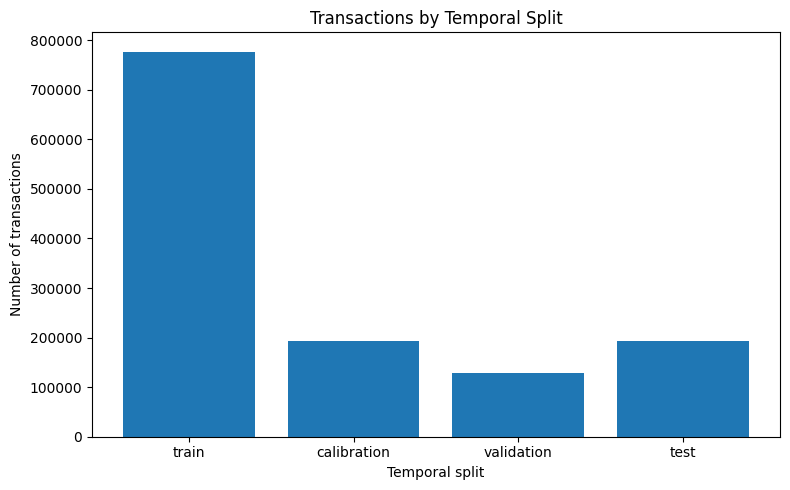

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    split_summary["split"],
    split_summary["rows"]
)

plt.xlabel("Temporal split")
plt.ylabel("Number of transactions")
plt.title("Transactions by Temporal Split")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/temporal_split_sizes.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 18. Visualize Fraud Rate by Split

Fraud prevalence is preserved as observed in each chronological period.

We do not rebalance Calibration, Validation, or Test.

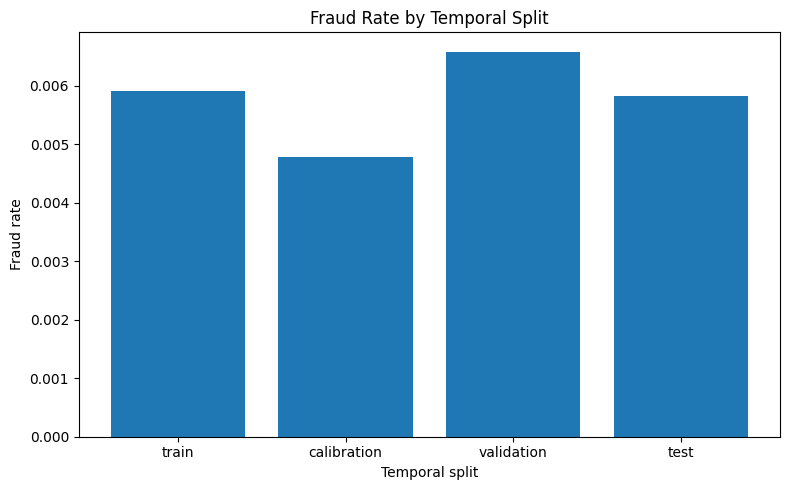

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    split_summary["split"],
    split_summary["fraud_rate"]
)

plt.xlabel("Temporal split")
plt.ylabel("Fraud rate")
plt.title("Fraud Rate by Temporal Split")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/temporal_split_fraud_rates.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 19. Visualize the Chronological Timeline

The horizontal bars show the retained time span of each split.

The empty spaces between bars correspond to the purge regions.

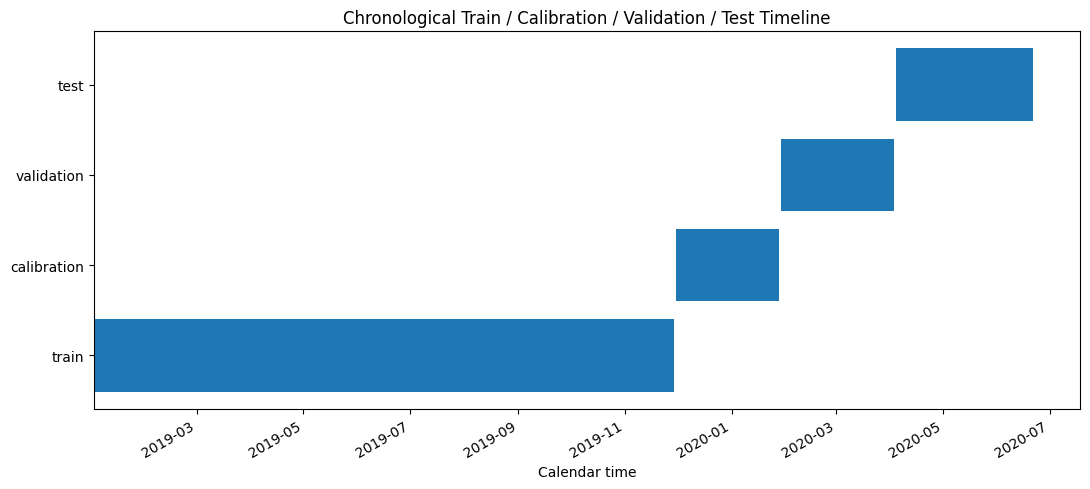

In [26]:
timeline = split_summary[
    ["split", "start_time", "end_time"]
].copy()

timeline["start_time"] = pd.to_datetime(timeline["start_time"])
timeline["end_time"] = pd.to_datetime(timeline["end_time"])

timeline["start_num"] = mdates.date2num(timeline["start_time"])
timeline["end_num"] = mdates.date2num(timeline["end_time"])
timeline["duration"] = timeline["end_num"] - timeline["start_num"]

fig, ax = plt.subplots(figsize=(11, 5))

y_positions = np.arange(len(timeline))

ax.barh(
    y_positions,
    timeline["duration"],
    left=timeline["start_num"]
)

ax.set_yticks(y_positions)
ax.set_yticklabels(timeline["split"])

ax.xaxis_date()
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

ax.set_xlabel("Calendar time")
ax.set_title(
    "Chronological Train / Calibration / Validation / Test Timeline"
)

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/temporal_split_timeline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 20. Save the Exact Split Metadata

Later notebooks should reproduce this exact split.

We save:

- ratios
- purge specification
- boundary indexes
- boundary timestamps
- retained period start/end times
- retained row counts
- purged row count

The large split dataframes themselves are **not** saved to GitHub.

In [27]:
split_metadata = {
    "dataset_path": DATA_PATH,

    "train_ratio": float(TRAIN_RATIO),
    "calibration_ratio": float(CALIBRATION_RATIO),
    "validation_ratio": float(VALIDATION_RATIO),
    "test_ratio": float(TEST_RATIO),

    "purge_hours_total": int(PURGE_HOURS),
    "purge_hours_each_side": float(HALF_PURGE_HOURS),

    "train_boundary_index": int(train_boundary_idx),
    "calibration_boundary_index": int(calibration_boundary_idx),
    "validation_boundary_index": int(validation_boundary_idx),

    "train_boundary_unix": int(train_boundary),
    "calibration_boundary_unix": int(calibration_boundary),
    "validation_boundary_unix": int(validation_boundary),

    "train_boundary_datetime": str(
        pd.to_datetime(train_boundary, unit="s")
    ),
    "calibration_boundary_datetime": str(
        pd.to_datetime(calibration_boundary, unit="s")
    ),
    "validation_boundary_datetime": str(
        pd.to_datetime(validation_boundary, unit="s")
    ),

    "train_start": str(train["trans_date_trans_time"].min()),
    "train_end": str(train["trans_date_trans_time"].max()),

    "calibration_start": str(
        calibration["trans_date_trans_time"].min()
    ),
    "calibration_end": str(
        calibration["trans_date_trans_time"].max()
    ),

    "validation_start": str(
        validation["trans_date_trans_time"].min()
    ),
    "validation_end": str(
        validation["trans_date_trans_time"].max()
    ),

    "test_start": str(test["trans_date_trans_time"].min()),
    "test_end": str(test["trans_date_trans_time"].max()),

    "train_rows": int(len(train)),
    "calibration_rows": int(len(calibration)),
    "validation_rows": int(len(validation)),
    "test_rows": int(len(test)),
    "purged_rows": int(purged_rows),
}

## 21. Save Results

This notebook saves:

### Results

- `sparkov_split_summary.csv`
- `sparkov_split_metadata.json`
- `sparkov_boundary_table.csv`
- `sparkov_purge_audit.csv`
- `sparkov_gap_summary.csv`
- `sparkov_split_overlap_summary.csv`
- `sparkov_entity_continuity.csv`

### Figures

- `temporal_split_sizes.png`
- `temporal_split_fraud_rates.png`
- `temporal_split_timeline.png`

These small artifacts can be committed to GitHub.

In [28]:
split_summary.to_csv(
    "/kaggle/working/results/sparkov_split_summary.csv",
    index=False
)

boundary_table.to_csv(
    "/kaggle/working/results/sparkov_boundary_table.csv",
    index=False
)

purge_audit.to_csv(
    "/kaggle/working/results/sparkov_purge_audit.csv",
    index=False
)

gap_summary.to_csv(
    "/kaggle/working/results/sparkov_gap_summary.csv",
    index=False
)

overlap_summary.to_csv(
    "/kaggle/working/results/sparkov_split_overlap_summary.csv",
    index=False
)

entity_continuity.to_csv(
    "/kaggle/working/results/sparkov_entity_continuity.csv",
    index=False
)

with open(
    "/kaggle/working/results/sparkov_split_metadata.json",
    "w"
) as f:
    json.dump(
        split_metadata,
        f,
        indent=4
    )

print("Split outputs saved.")

Split outputs saved.


## 22. Re-open the Saved Metadata

This is a simple reproducibility check to make sure the JSON file was written correctly.

In [29]:
with open(
    "/kaggle/working/results/sparkov_split_metadata.json",
    "r"
) as f:
    saved_metadata = json.load(f)

display(
    pd.DataFrame(
        saved_metadata.items(),
        columns=["key", "value"]
    )
)

,key,value
0,dataset_path,/kaggle/input/datasets/priyamchoksi/credit-car...
1,train_ratio,0.600000
2,calibration_ratio,0.150000
3,validation_ratio,0.100000
4,test_ratio,0.150000
5,purge_hours_total,24
6,purge_hours_each_side,12.000000
7,train_boundary_index,778005
8,calibration_boundary_index,972506
9,validation_boundary_index,1102173


## 23. Verify All Output Files

Before saving a Kaggle Version, confirm that the expected files are present.

In [30]:
print("Results:")
for filename in sorted(
    os.listdir("/kaggle/working/results")
):
    print("-", filename)

print("\nFigures:")
for filename in sorted(
    os.listdir("/kaggle/working/figures")
):
    print("-", filename)

Results:
- sparkov_boundary_table.csv
- sparkov_entity_continuity.csv
- sparkov_gap_summary.csv
- sparkov_purge_audit.csv
- sparkov_split_metadata.json
- sparkov_split_overlap_summary.csv
- sparkov_split_summary.csv

Figures:
- temporal_split_fraud_rates.png
- temporal_split_sizes.png
- temporal_split_timeline.png


## 24. Test Set Lock

From this point onward, the Test period is considered locked.

The Test set must not be used for:

- feature selection
- preprocessing decisions
- model selection
- hyperparameter tuning
- imbalance-strategy selection
- calibration-method selection
- threshold selection
- proxy-cost scenario selection
- daily alert-capacity selection

Development decisions should use Train, Calibration, and Validation.

This notebook may display basic Test properties such as row count or fraud count to confirm that the split is valid. Those values should not be used to redesign the model after the Test lock is established.

## 25. Methodology Notes

### Why chronological instead of random?

The real question is:

> If the model had been trained in the past, how would it perform on later transactions?

Chronological validation is closer to that deployment setting.

### Why a separate Calibration period?

Probability calibration should not be fitted on Validation or Test.

### Why a separate Validation period?

Validation is where development choices are compared.

### Why a separate Test period?

Test provides a final evaluation after the development pipeline has been frozen.

### Why a purge window?

Notebook 01 showed that fraud events can occur close together in time. A purge window reduces contamination from extremely adjacent transactions around split boundaries.

### What a purge window does not guarantee

It does not make periods entity-disjoint. The same card or merchant may legitimately appear in multiple periods because the task is future-time prediction.

## Conclusion

The Sparkov transaction stream has now been divided into a fixed chronological development design.

This notebook:

1. loaded and cleaned the dataset
2. sorted transactions chronologically
3. located 60% / 75% / 85% boundaries
4. applied a 24-hour total purge window around each boundary
5. created Train, Calibration, Validation, and Test periods
6. verified strict temporal ordering
7. verified transaction-ID separation
8. audited purged rows and actual time gaps
9. inspected basic entity continuity
10. saved the exact split specification and figures
11. locked the Test period for final evaluation

No predictive model was fitted.

## Next Notebook

`03_sparkov_baseline.ipynb`

The next notebook builds:

- Dummy Classifier
- Logistic Regression
- LightGBM

using current-transaction information only and Validation for development evaluation.